# Teste de Misspecificação do modelo de Regressão Linear Simples e as previsões para (2023-2026)

importações necessárias:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

from scipy import stats

Aqui iremos carregar a série temporal que processamos dos dados do porto

In [2]:
st = pd.read_csv('../data/processed/serietemporal.csv')

In [3]:
display(st)

,data,acucar,farelo_soja,milho,outros,graos_soja,porto
0,2005-01-01,581383.455,148641.973,67968.749,1675915.136,107966.285,5.027936e+06
1,2005-02-01,878015.791,207084.350,11623.584,1709254.262,390955.911,5.316605e+06
2,2005-03-01,610138.354,186525.305,12014.295,1730293.750,896454.461,5.899909e+06
3,2005-04-01,764282.986,340274.229,7687.881,1860562.606,858345.463,5.850636e+06
4,2005-05-01,1007703.226,330537.573,12814.725,2027806.818,1062494.325,6.826361e+06
...,...,...,...,...,...,...,...
252,2026-01-01,1561010.948,867668.554,1151919.295,2886627.208,699950.201,1.272810e+07
253,2026-02-01,1477114.383,625398.725,74968.470,2661940.849,3235398.809,1.317256e+07
254,2026-03-01,1159034.590,998819.742,4121.160,3166793.308,6095307.368,1.688558e+07
255,2026-04-01,953982.788,1062685.405,7957.515,2946290.344,6028032.753,1.649898e+07


Vamos criar um outro Data Frame fatiando os dados do período de dados reais que desejamos comparar (2023-2026)

In [4]:
st_2 = st.set_index(pd.to_datetime(st['data']))
real_st = st_2.loc[datetime(2023,1,1):].drop(columns=['data','acucar','farelo_soja','milho','outros','graos_soja'])

In [5]:
display(real_st.head(10))
print(len(real_st))

,porto
data,
2023-01-01,1.026399e+07
2023-02-01,1.098402e+07
2023-03-01,1.533587e+07
2023-04-01,1.373355e+07
2023-05-01,1.514737e+07
2023-06-01,1.560657e+07
2023-07-01,1.535087e+07
2023-08-01,1.515960e+07
2023-09-01,1.621269e+07


41


Vamos deixar salvo esse recorte dos dados reais para os outros modelos.

In [6]:
real_st.to_csv('../data/processed/real_st.csv')

O arquivo 'predict_RL.csv' foi extraído do notebook '3 Predições.ipynb' no diretório 'Sandbox_Reg_Lin'

In [7]:
rl = pd.read_csv('../data/external/predict_RL.csv', parse_dates=['data'], index_col = 0)
display(rl.head(10))
rl.dtypes

,data,porto
0,2023-01-01,9992517
1,2023-02-01,11986607
2,2023-03-01,14826853
3,2023-04-01,13829706
4,2023-05-01,13908953
5,2023-06-01,13456205
6,2023-07-01,14314263
7,2023-08-01,14296738
8,2023-09-01,13499045
9,2023-10-01,13449737


data     datetime64[ns]
porto             int64
dtype: object

Plotando em sobreposição os dados da previsão gerada pelo modelo de regressão linear simples juntamente aos valores reais que o porto movimentou.

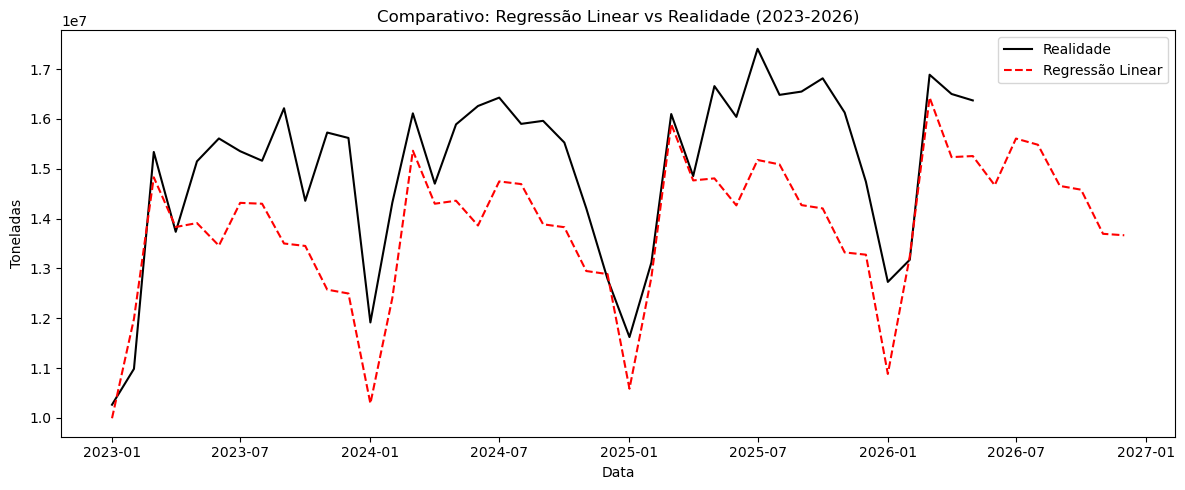

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(real_st.index, real_st['porto'], color='black', linewidth=1.5, label='Realidade')
ax.plot(rl['data'], rl['porto'], color='red', linewidth=1.5, linestyle='--', label='Regressão Linear')

ax.set_title('Comparativo: Regressão Linear vs Realidade (2023-2026)')
ax.set_xlabel('Data')
ax.set_ylabel('Toneladas')
ax.legend()
plt.tight_layout()
plt.show()

O trabalho de Santos, et al. (2023) demonstra como uma abordagem simples, baseada em regressão linear segmentada por mês, pode gerar previsões úteis para o planejamento logístico. Nosso objetivo aqui não é questionar a validade prática desses resultados, mas refletir sobre os fundamentos axiomáticos subjacentes. Conforme Aileen Nielsen (2021) discute no livro "Análise Prática de Séries Temporais", onde dedica-se um sub capítulo nesse tópico, apesar da sensibilidade desse modelo em séries temporais muitas vezes na prática os profissionais aplicam pois as consequências justificam os benefícios, assim como nesse caso uma curta previsão de 4 anos demonstrou-se eficiente em relação as violações matemáticas.

No entanto, apesar de o modelo apresentar um resultado há uma sutilidade que Mayo e Spanos apontam:
O modelo não pode ser usado para aprender sobre o fenômeno porque as inferências que ele produz não têm as propriedades estatísticas declaradas, portanto ele é não confiável como instrumento de inferência porque os pressupostos que garantem suas propriedades não foram verificados. Sendo um caso de Model-Misspecification.

In [9]:
# Resíduos extraídos diretamente do código original de Santos et al.
# Ver notebooks/Sandbox_Reg_Lin/3 Predições.ipynb

resid_in_sample_source = pd.read_csv(
    '../data/external/residuos_RL.csv', parse_dates=['data']
).set_index('data')

residuos_in_sample = resid_in_sample_source['residuo'].values

---

O Teorema de Gauss-Markov garante que o estimador OLS é BLUE (*Best Linear Unbiased Estimator*) **se e somente se** as seguintes        
     	  condições são satisfeitas:

1. **Linearidade** nos parâmetros
2. **Exogeneidade estrita** (E[ε|X] = 0)  
3. **Homocedasticidade** (Var(ε|X) = σ²)
4. **Ausência de autocorrelação** (Cov(εᵢ, εⱼ) = 0 para i ≠ j)
5. **Normalidade dos erros** (para inferência válida: p-valores, intervalos de confiança)

Vamos testar em ordem cada pressuposto.

## 3. Homocedasticidade
Teste de Breusch-Pagan — homocedasticidade dos resíduos

$H-0$: A variância dos resíduos é constante (homocedasticidade)

Se $p < 0.05$, rejeita-se $H-0$ (heterocedasticidade)

In [10]:
# Precisamos reconstruir o modelo OLS para ter acesso ao design matrix
# Usando uma tendência temporal como regressor (variável proxy), pois o modelo
# original de Santos et al. usa regressão linear simples com tendência
n = len(residuos_in_sample)
X_trend = sm.add_constant(np.arange(n))  # intercepto + tendência temporal

# Teste de Breusch-Pagan sobre os resíduos
bp_stat, bp_pvalue, bp_fstat, bp_fpvalue = het_breuschpagan(residuos_in_sample, X_trend)

print(f"Teste de Breusch-Pagan (homocedasticidade):")
print(f"  Estatística LM = {bp_stat:.4f}")
print(f"  p-valor (LM)    = {bp_pvalue:.6e}")
print(f"  Estatística F   = {bp_fstat:.4f}")
print(f"  p-valor (F)     = {bp_fpvalue:.6e}")
print()

if bp_pvalue < 0.05:
    print("Breusch-Pagan rejeita H₀: os resíduos são HETEROCEDÁSTICOS (p < 0.05)")
    print("Condição de Gauss-Markov VIOLADA (homocedasticidade)")
else:
    print("Breusch-Pagan não rejeita H₀: sem evidência de heterocedasticidade")
    print("Condição de Gauss-Markov: homocedasticidade não rejeitada")

Teste de Breusch-Pagan (homocedasticidade):
  Estatística LM = 19.0112
  p-valor (LM)    = 1.299524e-05
  Estatística F   = 20.6530
  p-valor (F)     = 9.201060e-06

Breusch-Pagan rejeita H₀: os resíduos são HETEROCEDÁSTICOS (p < 0.05)
Condição de Gauss-Markov VIOLADA (homocedasticidade)


## 4. Ausência de autocorrelação

Teste de Durbin-Watson — autocorrelação de primeira ordem

$H_0$: Não há autocorrelação de primeira ordem

Valores próximos de 2 indicam ausência; próximos de 0 indicam autocorrelação positiva

In [11]:
dw_stat = durbin_watson(residuos_in_sample)
print(f"Estatística de Durbin-Watson: {dw_stat:.4f}")
print()
if dw_stat < 1.5:
    print(f"DW = {dw_stat:.4f} << 2.0: FORTE evidência de autocorrelação positiva nos resíduos")
    print("Condição de Gauss-Markov VIOLADA (ausência de autocorrelação)")
elif dw_stat < 1.8:
    print(f"DW = {dw_stat:.4f} < 2.0: Evidência de autocorrelação positiva nos resíduos")
    print("Condição de Gauss-Markov VIOLADA (ausência de autocorrelação)")
else:
    print(f"DW = {dw_stat:.4f} ≈ 2.0: Sem evidência de autocorrelação de primeira ordem")

Estatística de Durbin-Watson: 0.9133

DW = 0.9133 << 2.0: FORTE evidência de autocorrelação positiva nos resíduos
Condição de Gauss-Markov VIOLADA (ausência de autocorrelação)


A função abaixo foi extraída do livro: Hyndman, R.J., Athanasopoulos, G., Garza, A., Challu, C., Mergenthaler, M., & Olivares, K.G. (2025). Forecasting: Principles and Practice, the Pythonic Way. (5.4 Residual diagnostics)

Acesse em: https://otexts.com/fpppy/05-toolbox.html#sec-residuals

In [12]:
def plot_diagnostics(data):
    _, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
    ax = axes["resid"]
    ax.plot(data["ds"], data["resid"])
    ax.set(title="Resíduos da RL")
    ax = axes["acf"]
    plot_acf(data["resid"].dropna(),
        zero=False, bartlett_confint=False, auto_ylims=True, ax=ax)
    ax.set(title="ACF Plot", xlabel="Lag (meses)", ylabel="acf")
    ax = axes["hist"]
    ax.hist(data["resid"], bins=20)
    ax.set(title="Histograma", xlabel="Resíduos", ylabel="Contagem")

plt.rcParams["figure.figsize"] = (13, 9)

Como podemos observar através do diagnóstico de resíduos a princípo vendo o histograma em torno da média 0 é um sinal positivo e a leitura do gráfico em linhas indica algo que não se pode assumir como sazonal ou ruído branco, mas de o principal e alarmante é o gráfico ACF que demonstra um padrão claro de sazonalidade conforme vimos anteriormente nos gráficos dos commodities, logo é muito capaz de a regressão ter capturado a tendência linear mas deixado a sazonalidade nos resíduos o que viola os pressupostos matemáticos do modelo.

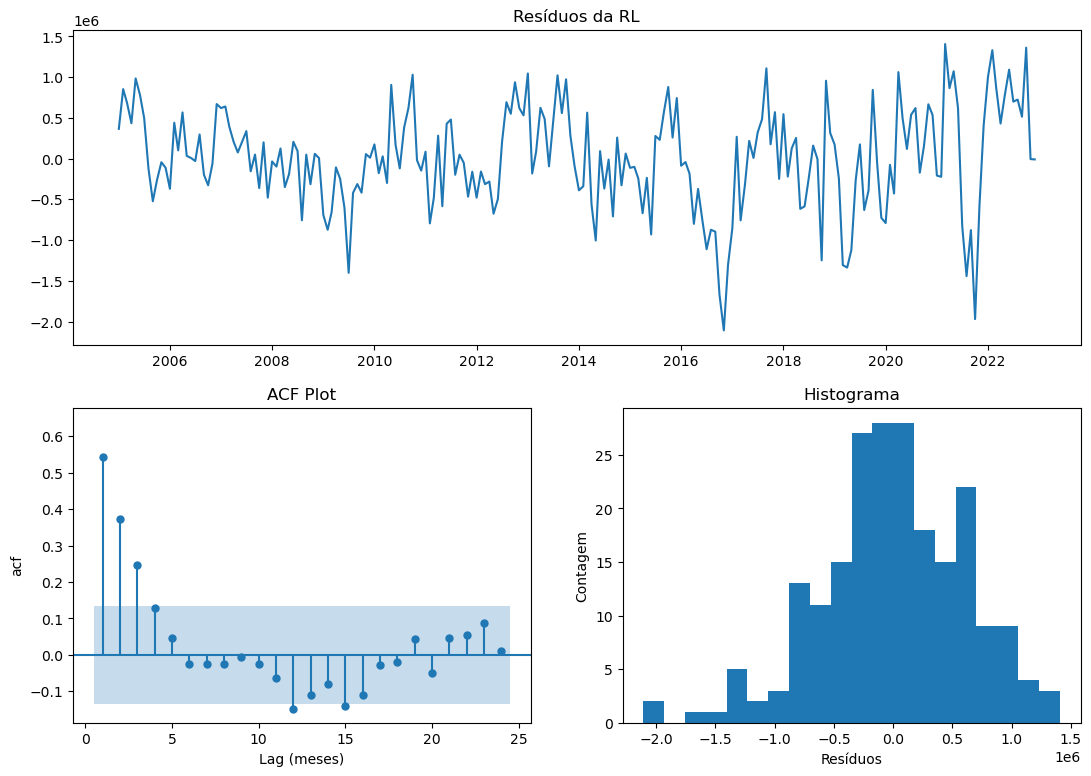

In [13]:
resid_df = pd.DataFrame({
    'ds': resid_in_sample_source.index,
    'resid': residuos_in_sample
})

plot_diagnostics(resid_df)

Vamos olhar mais a fundo no correlograma dos resíduos e note que de fato não se apresenta como ruído branco (o que se espera de um ACF de resíduos).

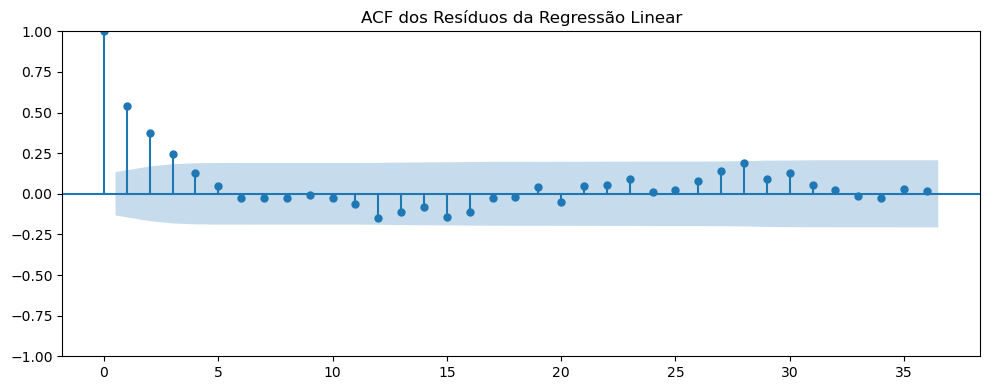

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(residuos_in_sample, lags=36, ax=ax)
ax.set_title('ACF dos Resíduos da Regressão Linear')
plt.tight_layout()
plt.show()

O teste de Ljung-Box serve para verificar autocorrelação positiva nos resíduos:

$ H_0: $ Não há autocorrelação positiva nos resíduos, se o $ p-valor < 0.05 $ então rejeita-se $ H_0 $

In [15]:
lb = acorr_ljungbox(residuos_in_sample, lags=[12, 24], return_df=True)
print(lb)
print()
print(lb.round(4))

       lb_stat     lb_pvalue
12  119.271741  8.632911e-20
24  135.410203  1.611766e-17

     lb_stat  lb_pvalue
12  119.2717        0.0
24  135.4102        0.0


## 5. Normalidade dos erros
Teste de Shapiro-Wilk — normalidade dos resíduos
$H_0$: Os resíduos seguem uma distribuição normal
Se $p < 0.05$, rejeita-se $H_0$

In [16]:
sw_stat, sw_pvalue = stats.shapiro(residuos_in_sample)
print(f"Teste de Shapiro-Wilk:")
print(f"  Estatística W = {sw_stat:.6f}")
print(f"  p-valor       = {sw_pvalue:.6e}")
print()

# Teste de Jarque-Bera (complementar)
jb_stat, jb_pvalue = stats.jarque_bera(residuos_in_sample)
skew_val = stats.skew(residuos_in_sample)    
kurt_val = stats.kurtosis(residuos_in_sample)

print(f"Teste de Jarque-Bera:")           
print(f"  Estatística JB = {jb_stat:.4f}")   
print(f"  p-valor         = {jb_pvalue:.6e}")
print(f"  Assimetria      = {skew_val:.4f}")
print(f"  Curtose         = {kurt_val:.4f}")

if sw_pvalue < 0.05:
    print("Shapiro-Wilk rejeita H₀: resíduos NÃO são normais (p < 0.05)")
else:
    print("Shapiro-Wilk não rejeita H₀: resíduos podem ser normais")
    
if jb_pvalue < 0.05:
    print("Jarque-Bera rejeita H₀: resíduos NÃO são normais (p < 0.05)")
else:
    print("Jarque-Bera não rejeita H₀: resíduos podem ser normais")

Teste de Shapiro-Wilk:
  Estatística W = 0.987275
  p-valor       = 5.096556e-02

Teste de Jarque-Bera:
  Estatística JB = 7.1148
  p-valor         = 2.851248e-02
  Assimetria      = -0.3870
  Curtose         = 0.4376
Shapiro-Wilk não rejeita H₀: resíduos podem ser normais
Jarque-Bera rejeita H₀: resíduos NÃO são normais (p < 0.05)
